# Tech Challenge — Fase 4
## Etapa 1: Coleta e Pré-processamento dos Dados

Este notebook cobre o **ponto 1** do desafio: coletar preços históricos de ações
via `yfinance` e preparar os dados para alimentar uma rede neural **LSTM**.

Fluxo:
1. Coleta dos dados (Yahoo Finance)
2. Inspeção e limpeza
3. Análise exploratória rápida
4. Seleção da feature alvo (`Close`)
5. Split treino/validação respeitando a ordem temporal
6. Escalonamento (MinMaxScaler)
7. Criação das janelas temporais (sequências) para a LSTM
8. Salvamento dos artefatos (arrays + scaler)


## 0. Instalação e imports

Caso esteja rodando localmente ou no Colab, descomente a linha de instalação.

In [15]:
# !pip install yfinance scikit-learn pandas numpy matplotlib joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib
import time
import yfinance as yf

# Reprodutibilidade
np.random.seed(42)

# Pasta para salvar os artefatos da etapa
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("Setup OK")

Setup OK


## 1. Coleta dos Dados

Defina o símbolo da empresa e o intervalo de datas. Aqui usamos a **Apple (AAPL)**
como exemplo — troque por qualquer ticker (ex: `DIS`, `MSFT`, `PETR4.SA` para a B3).

In [16]:
SYMBOL = "AAPL"
START_DATE = "2018-01-01"
END_DATE = "2026-06-20"

def baixar_dados(symbol, start, end, tentativas=3):
    for i in range(tentativas):
        df = yf.Ticker(symbol).history(start=start, end=end, auto_adjust=True)
        if not df.empty:
            return df
        print(f"Tentativa {i+1} vazia, aguardando...")
        time.sleep(2)
    raise ValueError(f"Sem dados para {symbol} após {tentativas} tentativas.")

df = baixar_dados(SYMBOL, START_DATE, END_DATE)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if df.empty:
    raise ValueError(
        f"Nenhum dado foi retornado para {SYMBOL} entre {START_DATE} e {END_DATE}. "
        "Verifique o ticker, ajuste o intervalo de datas ou tente novamente mais tarde."
    )

print(f"Linhas baixadas: {len(df)}")
df.head()

Linhas baixadas: 2127


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2018-01-02 00:00:00-05:00,39.776190,40.276431,39.565806,40.267078,102223600,0.0,0.0
2018-01-03 00:00:00-05:00,40.330195,40.802386,40.196955,40.260067,118071600,0.0,0.0
2018-01-04 00:00:00-05:00,40.332521,40.549917,40.224995,40.447063,89738400,0.0,0.0
2018-01-05 00:00:00-05:00,40.542909,40.994059,40.451743,40.907570,94640000,0.0,0.0
2018-01-08 00:00:00-05:00,40.755634,41.050168,40.657453,40.755634,82271200,0.0,0.0


## 2. Inspeção e Limpeza

Verificamos tipos, valores ausentes e a continuidade temporal.

In [17]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2127 entries, 2018-01-02 00:00:00-05:00 to 2026-06-18 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2127 non-null   float64
 1   High          2127 non-null   float64
 2   Low           2127 non-null   float64
 3   Close         2127 non-null   float64
 4   Volume        2127 non-null   int64  
 5   Dividends     2127 non-null   float64
 6   Stock Splits  2127 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 132.9 KB


In [18]:
# Valores ausentes por coluna
print("Valores ausentes:")
print(df.isna().sum())

# Datas duplicadas?
print("\nDatas duplicadas:", df.index.duplicated().sum())

Valores ausentes:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Datas duplicadas: 0


In [19]:
# Pregões não têm fins de semana/feriados, então gaps de calendário são esperados.
# Tratamos apenas NaNs internos (ex: dados faltantes pontuais) com forward fill.
df = df.sort_index()
df = df.ffill().dropna()

print("Após limpeza:", df.shape)
print("Período:", df.index.min().date(), "->", df.index.max().date())

Após limpeza: (2127, 7)
Período: 2018-01-02 -> 2026-06-18


## 3. Análise Exploratória Rápida

Visualizamos a série do preço de fechamento — é o que vamos prever.

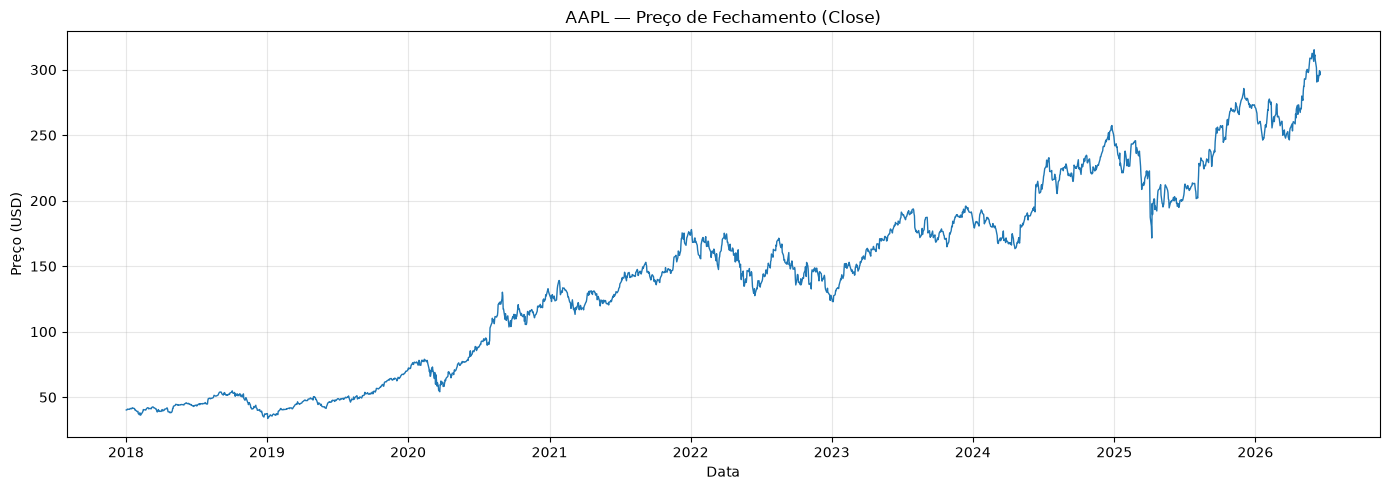

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], linewidth=1)
plt.title(f"{SYMBOL} — Preço de Fechamento (Close)")
plt.xlabel("Data")
plt.ylabel("Preço (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Estatísticas descritivas do alvo
df["Close"].describe()

count    2127.000000
mean      142.729557
std        72.052981
min        33.736988
25%        68.428780
50%       145.638199
75%       191.271706
max       315.200012
Name: Close, dtype: float64

## 4. Seleção da Feature Alvo

Para um primeiro modelo LSTM univariado, usamos apenas o **Close**.
(O array fica em formato 2D `(n_amostras, 1)` para o scaler.)

In [22]:
close_prices = df[["Close"]].copy()
print("Shape da série alvo:", close_prices.shape)
close_prices.tail()

Shape da série alvo: (2127, 1)


,Close
Date,
2026-06-12 00:00:00-04:00,291.130005
2026-06-15 00:00:00-04:00,296.420013
2026-06-16 00:00:00-04:00,299.239990
2026-06-17 00:00:00-04:00,295.950012
2026-06-18 00:00:00-04:00,298.010010


## 5. Split Treino / Validação (temporal)

**Importante:** em séries temporais **não** se embaralha os dados. O conjunto de
validação deve vir *depois* do de treino no tempo. Usamos 80% / 20%.

In [23]:
TRAIN_RATIO = 0.80
split_idx = int(len(close_prices) * TRAIN_RATIO)

train_data = close_prices.iloc[:split_idx]
valid_data = close_prices.iloc[split_idx:]

if train_data.empty or valid_data.empty:
    raise ValueError(
        "O split temporal gerou treino ou validação vazios. "
        "Revise a quantidade de dados disponível ou ajuste TRAIN_RATIO."
    )

print(f"Treino:    {len(train_data)} amostras "
      f"({train_data.index.min().date()} -> {train_data.index.max().date()})")
print(f"Validação: {len(valid_data)} amostras "
      f"({valid_data.index.min().date()} -> {valid_data.index.max().date()})")

Treino:    1701 amostras (2018-01-02 -> 2024-10-04)
Validação: 426 amostras (2024-10-07 -> 2026-06-18)


## 6. Escalonamento (MinMaxScaler)

Redes LSTM convergem melhor com dados em escala pequena (0 a 1).

**Cuidado com data leakage:** o scaler é ajustado (`fit`) **apenas no treino**
e depois apenas aplicado (`transform`) na validação.

In [24]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)   # fit só no treino
valid_scaled = scaler.transform(valid_data)       # transform na validação

print("Treino escalonado -> min:", train_scaled.min(), "max:", train_scaled.max())
print("Valid. escalonado -> min:", round(valid_scaled.min(), 4),
      "max:", round(valid_scaled.max(), 4))

Treino escalonado -> min: 0.0 max: 1.0
Valid. escalonado -> min: 0.6921 max: 1.4139


## 7. Criação das Janelas Temporais

A LSTM aprende a partir de **sequências**. Para prever o dia `t`, usamos os
`WINDOW_SIZE` dias anteriores.

- `X`: blocos de `WINDOW_SIZE` preços consecutivos -> shape `(amostras, janela, 1)`
- `y`: o preço do dia seguinte a cada bloco

Para a validação, prefixamos os últimos `WINDOW_SIZE` dias do treino, de modo que
as primeiras previsões de validação tenham histórico suficiente.

In [25]:
WINDOW_SIZE = 60  # nº de dias usados para prever o próximo

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    X = np.array(X)
    y = np.array(y)
    # LSTM espera entrada 3D: (amostras, timesteps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

# Treino
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)

# Validação: anexa os últimos WINDOW_SIZE dias do treino para dar contexto
valid_input = np.concatenate([train_scaled[-WINDOW_SIZE:], valid_scaled], axis=0)
X_valid, y_valid = create_sequences(valid_input, WINDOW_SIZE)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "| y_valid:", y_valid.shape)

X_train: (1641, 60, 1) | y_train: (1641,)
X_valid: (426, 60, 1) | y_valid: (426,)


## 8. Salvamento dos Artefatos

Guardamos os arrays prontos e o **scaler** (essencial: a API precisará dele para
escalonar a entrada e reverter a previsão para a escala de preço real).

In [26]:
np.save(os.path.join(ARTIFACTS_DIR, "X_train.npy"), X_train)
np.save(os.path.join(ARTIFACTS_DIR, "y_train.npy"), y_train)
np.save(os.path.join(ARTIFACTS_DIR, "X_valid.npy"), X_valid)
np.save(os.path.join(ARTIFACTS_DIR, "y_valid.npy"), y_valid)

joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "scaler.pkl"))

# Salva também o dataframe limpo para referência/reuso
df.to_csv(os.path.join(ARTIFACTS_DIR, f"{SYMBOL}_clean.csv"))

# Metadados úteis para as próximas etapas
meta = {
    "symbol": SYMBOL,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "window_size": WINDOW_SIZE,
    "train_ratio": TRAIN_RATIO,
    "feature": "Close",
}
joblib.dump(meta, os.path.join(ARTIFACTS_DIR, "meta.pkl"))

print("Artefatos salvos em:", os.path.abspath(ARTIFACTS_DIR))
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    print(" -", f)

Artefatos salvos em: /home/doglas/Documents/FIAP/fiap-tech-challenge-4/artifacts
 - AAPL_clean.csv
 - X_train.npy
 - X_valid.npy
 - meta.pkl
 - metrics.pkl
 - scaler.pkl
 - y_train.npy
 - y_valid.npy


## Pronto ✅

A etapa 1 está completa. Os artefatos gerados (`X_train`, `y_train`, `X_valid`,
`y_valid`, `scaler.pkl`, `meta.pkl`) alimentam diretamente a **etapa 2**
(construção e treino do modelo LSTM).

**Próximos passos sugeridos:**
- Etapa 2: montar a arquitetura LSTM no Keras/TensorFlow, treinar e avaliar (MAE, RMSE, MAPE)
- Etapa 3: salvar o modelo treinado (`.keras`)
- Etapa 4: servir via FastAPI/Flask
